# Goal Kick Sequence Visualization
**Purpose:** Validate that `01_filter_goal_kicks.py` correctly extracted goal kick sequences.
Plots a single sample sequence — player positions at the opening frame and ball trajectory with event markers across the full sequence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mplsoccer import Pitch
from pathlib import Path

## 1. Load data and pick a sample sequence

In [2]:
PROJECT_ROOT = Path("../")
GOAL_KICK_FILE = PROJECT_ROOT / "data" / "feature_engineering" / "goal_kick_sequences.parquet"

df = pd.read_parquet(GOAL_KICK_FILE)

# Pick the first sequence
SAMPLE_ID = df["goal_kick_id"].iloc[0]
seq = df[df["goal_kick_id"] == SAMPLE_ID].copy()

print(f"Total sequences in dataset : {df['goal_kick_id'].nunique():,}")
print(f"Sampled goal_kick_id       : {SAMPLE_ID}")
print(f"Rows in sequence           : {len(seq):,}")
print(f"Unique frames              : {seq['frame'].nunique()}")

Total sequences in dataset : 5,593
Sampled goal_kick_id       : 1
Rows in sequence           : 9,240
Unique frames              : 420


## 2. Sequence metadata

In [3]:
row0 = seq.iloc[0]
poss_team   = seq["possession_team_name"].iloc[0]
def_team    = seq.loc[seq["possession_team_name"] != seq["possession_team_name"], "event_team_name"].unique()

# Identify defending team from skc_team_id
poss_team_skc = seq.loc[seq["possession_team_name"] == poss_team, "skc_team_id"].dropna()
poss_skc_id   = poss_team_skc.mode()[0] if not poss_team_skc.empty else None

events_in_seq = seq.drop_duplicates("event_id")[["event_type","event_location_x","event_location_y"]]

print("=" * 50)
print(f"  Match        : {row0['home_team']} vs {row0['away_team']}")
print(f"  Match ID     : {row0['skc_match_id']}")
print(f"  Period       : {row0['period']}")
print(f"  Kick-off at  : {row0['timestamp_seconds']:.1f}s")
print(f"  Possession   : {poss_team}")
print(f"  play_pattern : {row0['play_pattern']}")
print("=" * 50)
print(f"\nEvents ({len(events_in_seq)}):")
print(events_in_seq["event_type"].value_counts().to_string())

  Match        : Nagoya Grampus vs Kashima Antlers
  Match ID     : 1410827
  Period       : 1
  Kick-off at  : 421.8s
  Possession   : Kashima Antlers
  play_pattern : From Goal Kick

Events (70):
event_type
Carry            28
Pass             26
Ball Recovery     8
Ball Receipt*     3
Pressure          3
Duel              2


## 3. Coordinate helpers
SkillCorner tracking uses **pitch-centre origin, metres** (x: −52.5 → 52.5, y: −34 → 34).  
StatsBomb events use **top-left origin** (x: 0 → 120, y: 0 → 80).  
We convert tracking coords to StatsBomb space for a unified mplsoccer canvas.

In [4]:
def skc_to_sb(x, y):
    """Convert SkillCorner (centre-origin, metres) to StatsBomb (0-120, 0-80)."""
    sb_x = (x + 52.5) * (120 / 105)
    sb_y = (y + 34.0) * (80  / 68)
    return sb_x, sb_y

# Apply to tracking columns
seq[["px_sb", "py_sb"]] = pd.DataFrame(
    [skc_to_sb(r.player_x, r.player_y) for r in seq.itertuples()],
    index=seq.index
)
seq[["bx_sb", "by_sb"]] = pd.DataFrame(
    [skc_to_sb(r.ball_x, r.ball_y) for r in seq.itertuples()],
    index=seq.index
)

print("Coordinate conversion done.")
print(f"  player_x range (SKC): [{seq['player_x'].min():.1f}, {seq['player_x'].max():.1f}]")
print(f"  px_sb    range (SB) : [{seq['px_sb'].min():.1f}, {seq['px_sb'].max():.1f}]")

Coordinate conversion done.
  player_x range (SKC): [-55.0, 41.4]
  px_sb    range (SB) : [-2.8, 107.3]


## Plot 1 — Opening frame: player positions

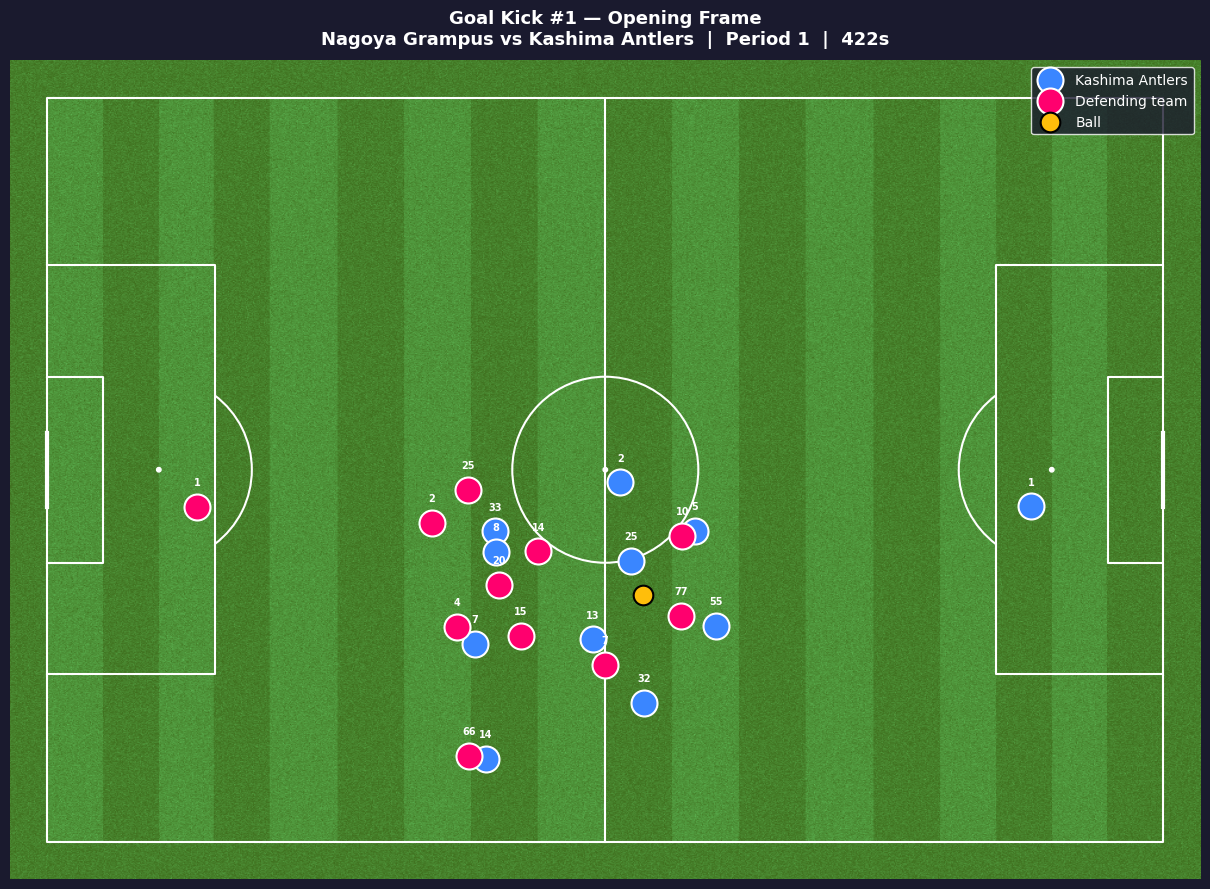

In [5]:
# First tracking frame
first_frame = seq["frame"].min()
frame0 = seq[seq["frame"] == first_frame].copy()

# Identify possession team rows by skc_team_id
poss_skc_id = frame0.loc[
    frame0["possession_team_name"] == poss_team, "skc_team_id"
].dropna().mode()
poss_skc_id = poss_skc_id[0] if not poss_skc_id.empty else None

poss_players = frame0[frame0["skc_team_id"] == poss_skc_id]
def_players  = frame0[frame0["skc_team_id"] != poss_skc_id]

# Ball position (same for all rows in a frame)
bx0, by0 = frame0[["bx_sb", "by_sb"]].iloc[0]

pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white",
              stripe=True, linewidth=1.5)
fig, ax = pitch.draw(figsize=(14, 9))
fig.patch.set_facecolor("#1a1a2e")

# Possession team
pitch.scatter(
    poss_players["px_sb"], poss_players["py_sb"],
    ax=ax, s=350, color="#3a86ff", edgecolors="white", linewidths=1.5,
    zorder=5, label=poss_team
)
# Defending team
pitch.scatter(
    def_players["px_sb"], def_players["py_sb"],
    ax=ax, s=350, color="#ff006e", edgecolors="white", linewidths=1.5,
    zorder=5, label="Defending team"
)
# Ball
pitch.scatter(
    [bx0], [by0],
    ax=ax, s=200, color="#ffbe0b", edgecolors="black", linewidths=1.5,
    marker="o", zorder=6, label="Ball"
)

# Player labels
for _, p in frame0.iterrows():
    label = p["jersey_number"] if not pd.isna(p.get("jersey_number")) else ""
    ax.text(
        p["px_sb"], p["py_sb"] - 3.2,
        str(int(label)) if label != "" else "",
        ha="center", va="top", fontsize=7, color="white", fontweight="bold", zorder=7
    )

ax.legend(
    loc="upper right", fontsize=10,
    facecolor="#1a1a2e", labelcolor="white", edgecolor="white"
)
ax.set_title(
    f"Goal Kick #{SAMPLE_ID} — Opening Frame\n"
    f"{row0['home_team']} vs {row0['away_team']}  |  "
    f"Period {int(row0['period'])}  |  {row0['timestamp_seconds']:.0f}s",
    color="white", fontsize=13, fontweight="bold", pad=12
)
plt.tight_layout()
plt.show()

## Plot 2 — Ball trajectory + event annotations across full sequence

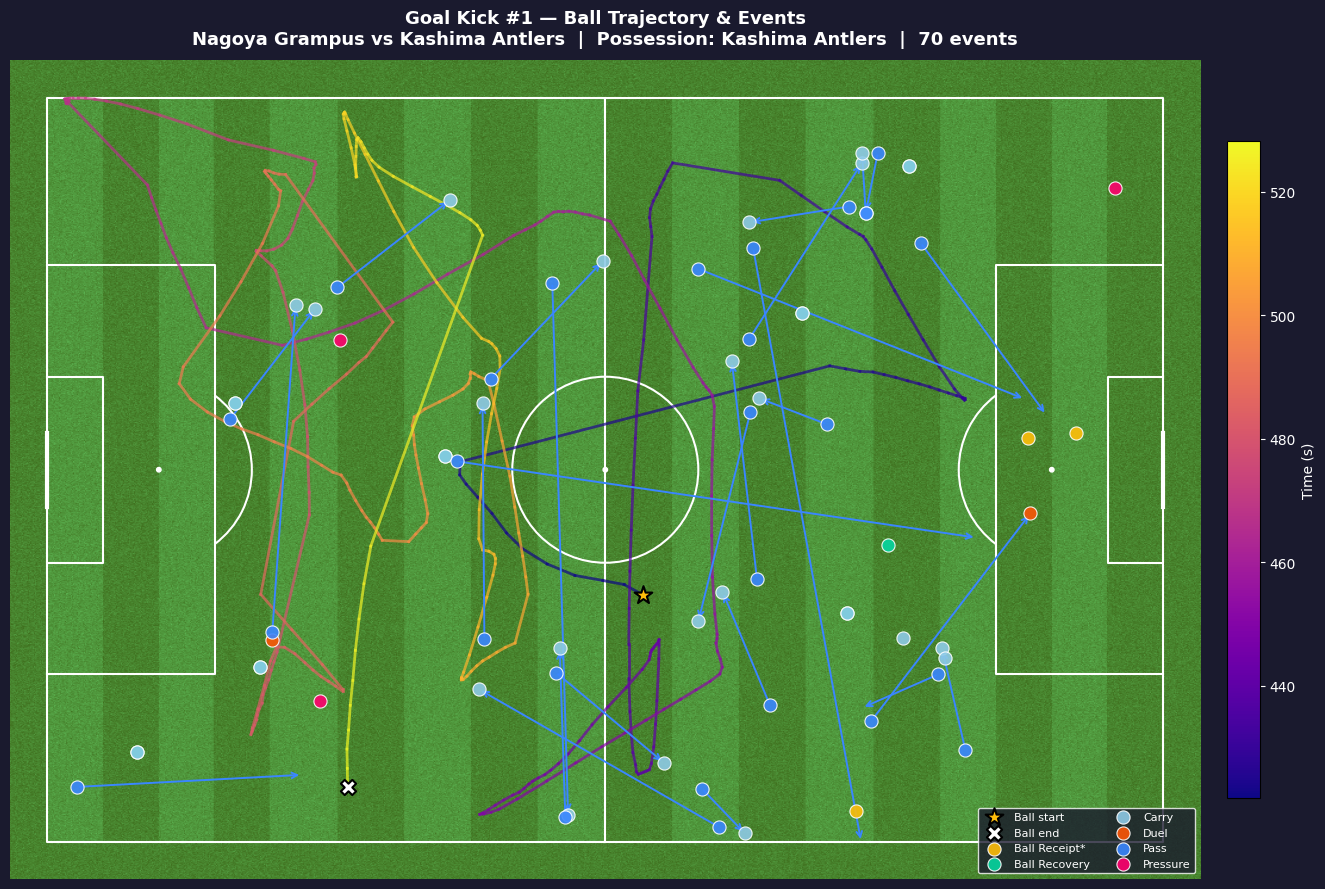

In [6]:
# One row per frame for ball trajectory (any player row per frame is fine)
ball_traj = (
    seq.groupby("frame", sort=True)[["bx_sb", "by_sb", "timestamp_seconds"]]
    .first()
    .reset_index()
)

# Unique events with StatsBomb coords
events = seq.drop_duplicates("event_id").dropna(subset=["event_location_x", "event_location_y"]).copy()

# Event colours
EVENT_COLORS = {
    "Pass"           : "#3a86ff",
    "Carry"          : "#8ecae6",
    "Ball Recovery"  : "#06d6a0",
    "Pressure"       : "#ff006e",
    "Duel"           : "#fb5607",
    "Ball Receipt*"  : "#ffbe0b",
    "Clearance"      : "#9b5de5",
    "Shot"           : "#f15bb5",
}
DEFAULT_COLOR = "#aaaaaa"

pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white",
              stripe=True, linewidth=1.5)
fig, ax = pitch.draw(figsize=(14, 9))
fig.patch.set_facecolor("#1a1a2e")

# --- Ball trajectory coloured by time ---
n_frames = len(ball_traj)
cmap = plt.cm.plasma
for i in range(n_frames - 1):
    x0, y0 = ball_traj["bx_sb"].iloc[i],   ball_traj["by_sb"].iloc[i]
    x1, y1 = ball_traj["bx_sb"].iloc[i+1], ball_traj["by_sb"].iloc[i+1]
    color = cmap(i / max(n_frames - 1, 1))
    ax.plot([x0, x1], [y0, y1], color=color, linewidth=2, alpha=0.7, zorder=3)

# Ball start / end markers
ax.scatter(
    ball_traj["bx_sb"].iloc[0], ball_traj["by_sb"].iloc[0],
    s=180, color="#ffbe0b", edgecolors="black", linewidths=1.5,
    marker="*", zorder=7, label="Ball start"
)
ax.scatter(
    ball_traj["bx_sb"].iloc[-1], ball_traj["by_sb"].iloc[-1],
    s=120, color="white", edgecolors="black", linewidths=1.5,
    marker="X", zorder=7, label="Ball end"
)

# --- Event markers ---
for etype, grp in events.groupby("event_type"):
    color = EVENT_COLORS.get(etype, DEFAULT_COLOR)
    ax.scatter(
        grp["event_location_x"], grp["event_location_y"],
        s=90, color=color, edgecolors="white", linewidths=0.8,
        zorder=6, label=etype, alpha=0.9
    )

# Pass arrows
passes = events[(events["event_type"] == "Pass") & events["pass_end_x"].notna()]
for _, p in passes.iterrows():
    ax.annotate(
        "", xy=(p["pass_end_x"], p["pass_end_y"]),
        xytext=(p["event_location_x"], p["event_location_y"]),
        arrowprops=dict(arrowstyle="->", color="#3a86ff", lw=1.4),
        zorder=5
    )

# Colourbar for ball trajectory (time)
sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=ball_traj["timestamp_seconds"].min(),
                        vmax=ball_traj["timestamp_seconds"].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.025, pad=0.02)
cbar.set_label("Time (s)", color="white", fontsize=10)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax.legend(
    loc="lower right", fontsize=8, ncol=2,
    facecolor="#1a1a2e", labelcolor="white", edgecolor="white"
)
ax.set_title(
    f"Goal Kick #{SAMPLE_ID} — Ball Trajectory & Events\n"
    f"{row0['home_team']} vs {row0['away_team']}  |  "
    f"Possession: {poss_team}  |  {len(events)} events",
    color="white", fontsize=13, fontweight="bold", pad=12
)
plt.tight_layout()
plt.show()

## Plot 3 — Player trajectories over the full sequence

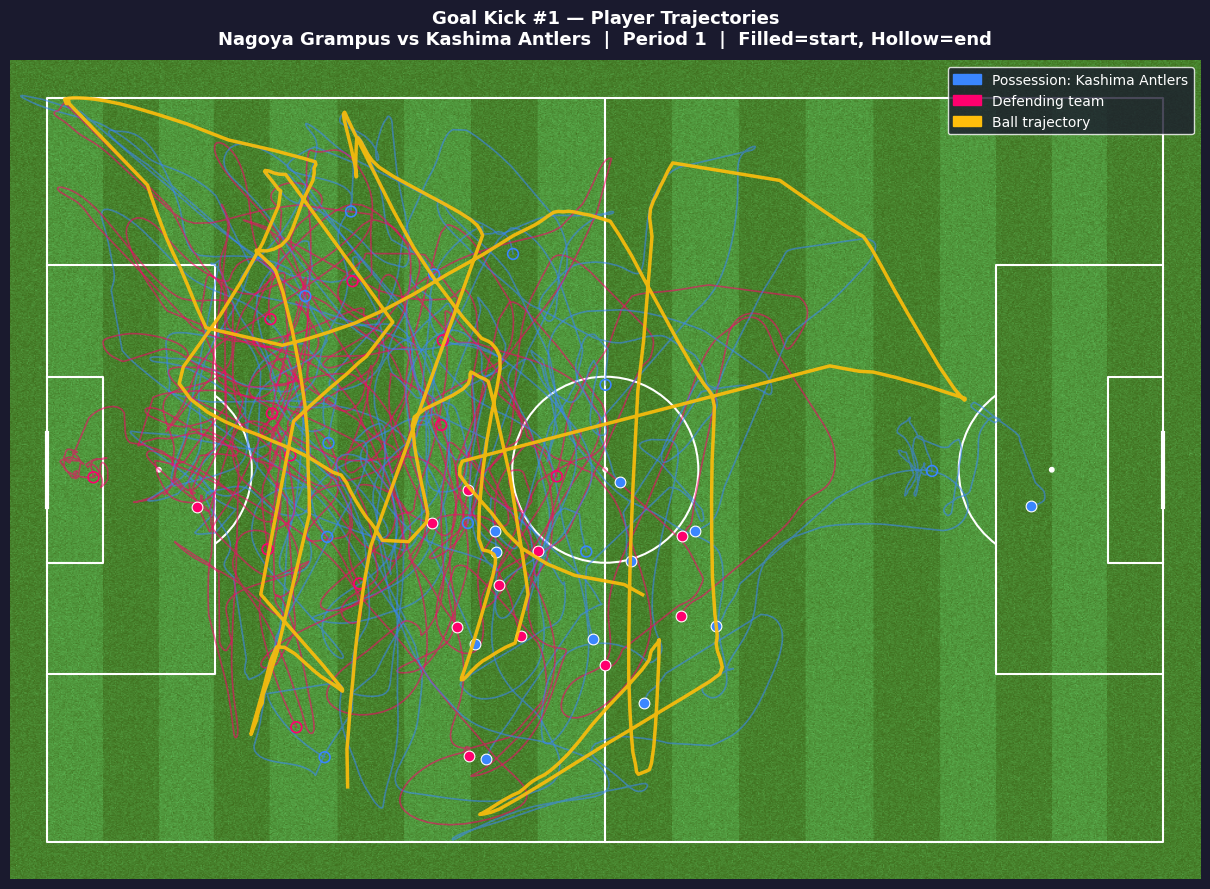

In [7]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white",
              stripe=True, linewidth=1.5)
fig, ax = pitch.draw(figsize=(14, 9))
fig.patch.set_facecolor("#1a1a2e")

for player_id, player_df in seq.groupby("player_id"):
    player_df = player_df.sort_values("frame")
    is_poss   = (player_df["skc_team_id"].iloc[0] == poss_skc_id)
    color     = "#3a86ff" if is_poss else "#ff006e"
    alpha     = 0.55

    ax.plot(
        player_df["px_sb"], player_df["py_sb"],
        color=color, linewidth=1.2, alpha=alpha, zorder=3
    )
    # Start dot
    ax.scatter(
        player_df["px_sb"].iloc[0], player_df["py_sb"].iloc[0],
        s=60, color=color, edgecolors="white", linewidths=0.8, zorder=5
    )
    # End dot (hollow)
    ax.scatter(
        player_df["px_sb"].iloc[-1], player_df["py_sb"].iloc[-1],
        s=60, facecolors="none", edgecolors=color, linewidths=1.2, zorder=5
    )

# Ball trajectory on top
ax.plot(ball_traj["bx_sb"], ball_traj["by_sb"],
        color="#ffbe0b", linewidth=2.5, alpha=0.9, zorder=6, label="Ball")

legend_handles = [
    mpatches.Patch(color="#3a86ff", label=f"Possession: {poss_team}"),
    mpatches.Patch(color="#ff006e", label="Defending team"),
    mpatches.Patch(color="#ffbe0b", label="Ball trajectory"),
]
ax.legend(
    handles=legend_handles, loc="upper right", fontsize=10,
    facecolor="#1a1a2e", labelcolor="white", edgecolor="white"
)
ax.set_title(
    f"Goal Kick #{SAMPLE_ID} — Player Trajectories\n"
    f"{row0['home_team']} vs {row0['away_team']}  |  "
    f"Period {int(row0['period'])}  |  Filled=start, Hollow=end",
    color="white", fontsize=13, fontweight="bold", pad=12
)
plt.tight_layout()
plt.show()